# Simple linear regression

## Import the relevant libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## Load the data

In [3]:
data = pd.read_csv('1.01. Simple linear regression.csv')

In [4]:
data

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83
...,...,...
79,1936,3.71
80,1810,3.71
81,1987,3.73
82,1962,3.76


In [5]:
data.describe()

,SAT,GPA
count,84.000000,84.000000
mean,1845.273810,3.330238
std,104.530661,0.271617
min,1634.000000,2.400000
25%,1772.000000,3.190000
50%,1846.000000,3.380000
75%,1934.000000,3.502500
max,2050.000000,3.810000


## Create your first regression

### Define the dependend and the independent variables

In [6]:
y = data['GPA'] # dependent variable
x1 = data['SAT'] # independent variable

### Explore the data

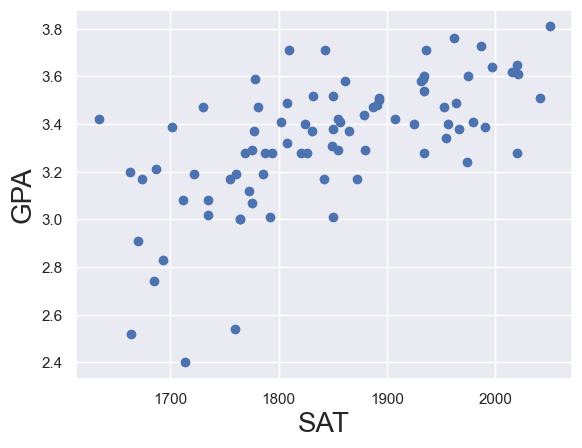

In [7]:
sns.set_theme()
plt.scatter(x1,y)
plt.xlabel('SAT', fontsize=20)
plt.ylabel('GPA', fontsize=20)
plt.show()

### Regression itself

In [ ]:
x = sm.add_constant(x1) # adding a constant to the model (y = b0 + b1x1)
results = sm.OLS(y,x).fit() # Ordinary Least Squares

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     56.05
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           7.20e-11
Time:                        16:55:41   Log-Likelihood:                 12.672
No. Observations:                  84   AIC:                            -21.34
Df Residuals:                      82   BIC:                            -16.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2750      0.409      0.673      0.503      -0.538       1.088
SAT            0.0017      0.000      7.487      0.000       0.001       0.002
==============================================================================
Omnibus:                       12.839   Durbin-Watson:                   0.950
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.155
Skew:                          -0.722   Prob(JB):                     0.000310
Kurtosis:                       4.590   Cond. No.                     3.29e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.29e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [25]:
print(results.summary().as_text()) # summary of the regression

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     56.05
Date:                Sat, 22 Feb 2025   Prob (F-statistic):           7.20e-11
Time:                        18:31:56   Log-Likelihood:                 12.672
No. Observations:                  84   AIC:                            -21.34
Df Residuals:                      82   BIC:                            -16.48
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2750      0.409      0.673      0.5

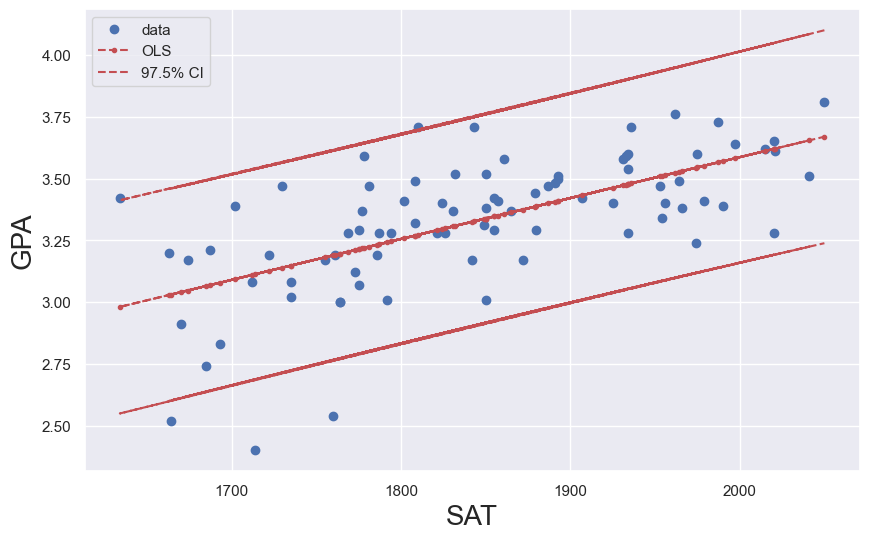

In [29]:
pred_ols = results.get_prediction()
iv_l = pred_ols.summary_frame()['obs_ci_lower']
iv_u = pred_ols.summary_frame()['obs_ci_upper']

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(x1, y, 'o', label='data')
ax.plot(x1, results.fittedvalues, 'r--.', label='OLS')
ax.plot(x1, iv_u, 'r--', label='97.5% CI')
ax.plot(x1, iv_l, 'r--')
ax.legend(loc='best')
plt.xlabel('SAT', fontsize=20)
plt.ylabel('GPA', fontsize=20)
plt.show()

In [26]:
print(f"Standard errors: {results.bse}")

Standard errors: const    0.408739
SAT      0.000221
dtype: float64


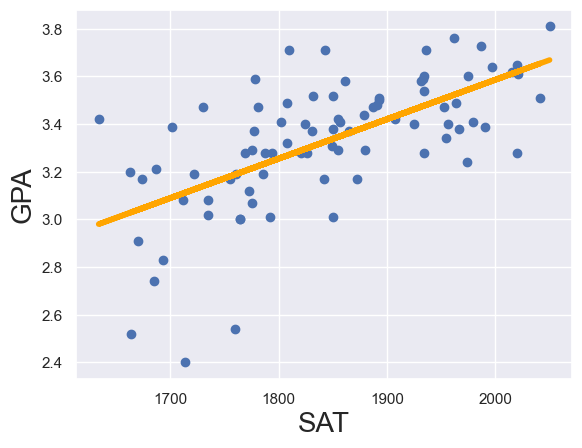

In [9]:
plt.scatter(x1,y)
yhat = results.params['const'] + results.params['SAT'] * x1
plt.xlabel('SAT', fontsize=20)
plt.ylabel('GPA', fontsize=20)
plt.plot(x1, yhat, lw=4, c='orange', label='regression line')  # regression line
plt.show()

/var/folders/_w/1s9g2lr949nf_6v9dmx3s7mc0000gq/T/ipykernel_82861/970051350.py:2: RuntimeWarning: divide by zero encountered in divide
  y_new = 1 / np.sqrt(x_new)


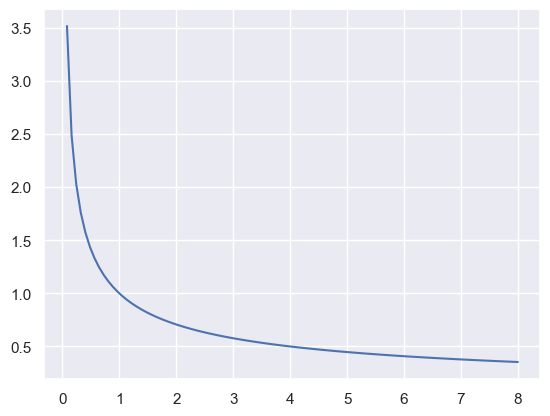

In [10]:
x_new = np.linspace(0, 8, 100)
y_new = 1 / np.sqrt(x_new)
plt.plot(x_new, y_new)
plt.show()

In [37]:
ols_pred = results.get_prediction()
print(ols_pred.summary_frame(alpha=0.01).head())

       mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  3.112890  0.037026       3.015248       3.210531      2.548965   
1  3.030105  0.046209       2.908247       3.151963      2.461487   
2  3.189051  0.029727       3.110657       3.267446      2.628139   
3  3.064875  0.042243       2.953476       3.176274      2.498406   
4  3.078120  0.040769       2.970606       3.185634      2.512403   

   obs_ci_upper  
0      3.676814  
1      3.598723  
2      3.749964  
3      3.631343  
4      3.643838  


In [40]:
np.std(y - results.params["const"]) / np.sqrt(len(y))

np.float64(0.029458922643450788)

In [13]:
results.params["const"]

np.float64(0.27504029966029075)

In [14]:
0.0017*1850 + 0.275

3.42

In [16]:
np.std(y) / np.sqrt(len(y))

np.float64(0.02945892264345078)

In [18]:
np.std(y) 

np.float64(0.2699954858109236)

In [19]:
y

0     2.40
1     2.52
2     2.54
3     2.74
4     2.83
      ... 
79    3.71
80    3.71
81    3.73
82    3.76
83    3.81
Name: GPA, Length: 84, dtype: float64